In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
iris = load_iris()

In [3]:
print(iris.DESCR)
print("Klasser:", iris.target_names)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
X, y = load_iris(return_X_y=True, as_frame=True)

In [5]:
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split( X, y, test_size=0.2, random_state=40)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

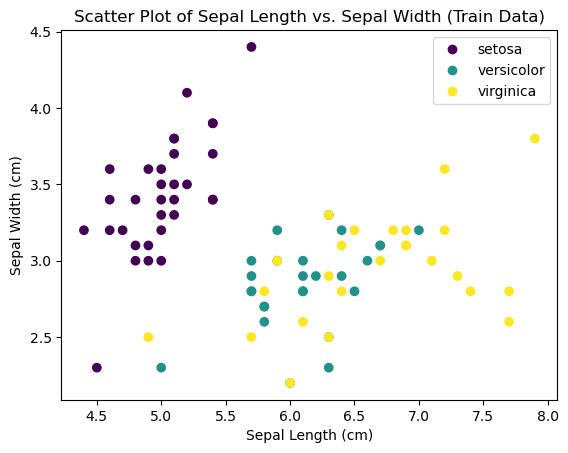

In [8]:
classes = ['setosa', 'versicolor', 'virginica']

scatter = plt.scatter(
    X_train['sepal length (cm)'],
    X_train['sepal width (cm)'],
    c=y_train
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

In [9]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [10]:
y_val_pred = model.predict(X_val)

print("Accuracy på valideringsdata:", round(accuracy_score(y_val, y_val_pred), 3))
print("\nClassification report på valideringsdata:")
print(classification_report(y_val, y_val_pred, target_names=classes))

Accuracy på valideringsdata: 0.694

Classification report på valideringsdata:
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36



In [11]:
model.fit(X_train_full, y_train_full)

LogisticRegression(max_iter=200)

In [12]:
y_test_pred = model.predict(X_test)

print("Accuracy på testdata:", round(accuracy_score(y_test, y_test_pred), 3))
print("\nClassification report på testdata:")
print(classification_report(y_test, y_test_pred, target_names=classes))

Accuracy på testdata: 0.933

Classification report på testdata:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



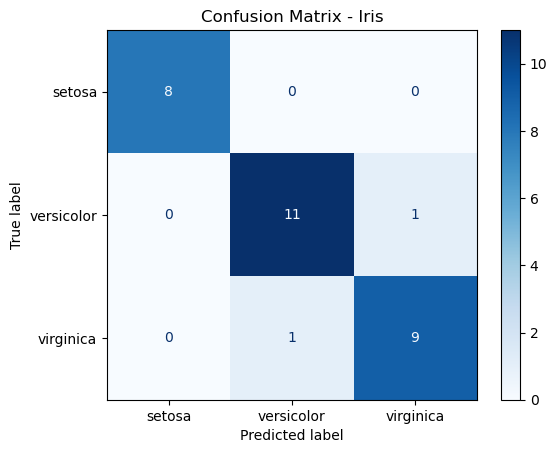

In [13]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Iris")
plt.show()

In [14]:
new_flower = pd.DataFrame({
    'sepal length (cm)': [5.1],
    'sepal width (cm)': [3.5]
})

prediction = model.predict(new_flower)
predicted_class = iris.target_names[prediction[0]]

print("Ny observation predikteras som:", predicted_class)

Ny observation predikteras som: setosa
